In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('data.csv')

In [3]:
import pandas as pd

# Sort to ensure chronological order
df = df.sort_values('recording_time_ns').reset_index(drop=True)

# Define the maximum expected gap between rows within the same experiment
# (e.g., 1e9 nanoseconds = 1 second)
threshold_ns = 1e9 

# True where a new block starts, False otherwise
is_new_experiment = df['recording_time_ns'].diff() > threshold_ns

# Cumulative sum assigns a monotonically increasing integer to each contiguous block
df['experiment_id'] = is_new_experiment.cumsum()

# Split into a list of DataFrames
experiment_dfs = [group for _, group in df.groupby('experiment_id')]

In [ ]:
experiment_idx = 3
experiment_data = df[df['experiment_id'] == experiment_idx]
experiment_data

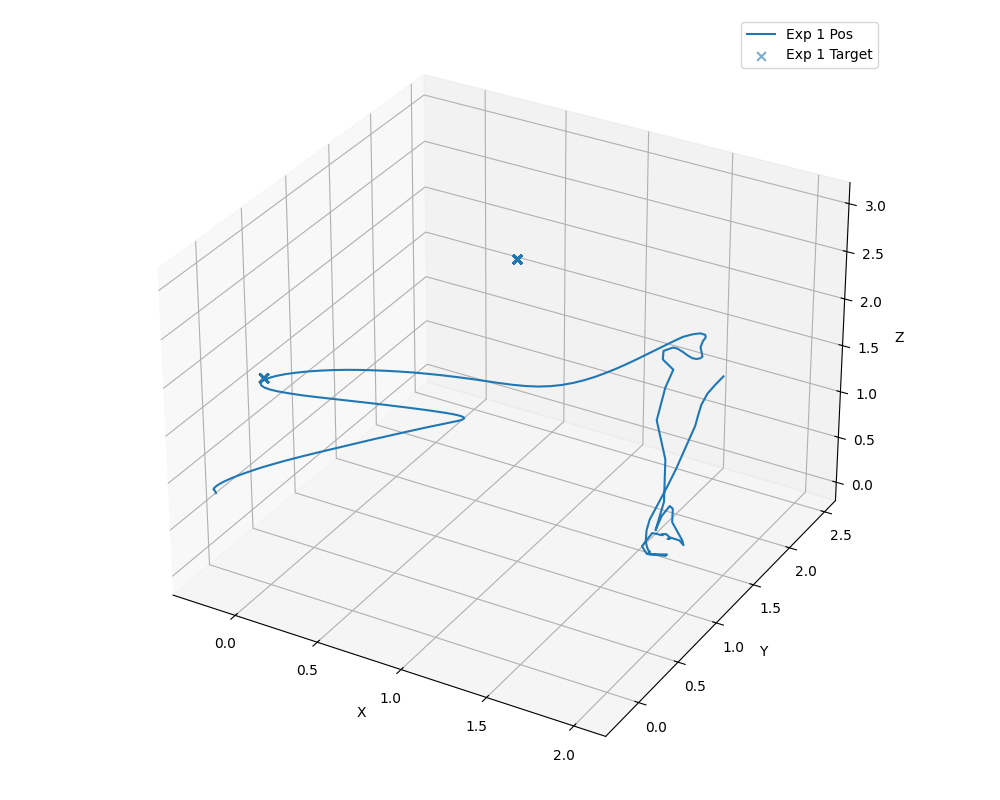

In [14]:
%matplotlib widget
import matplotlib.pyplot as plt

def plot_trajectories_3d(experiment_dfs):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    for i, df in enumerate(experiment_dfs):
        line = ax.plot(
            df['pos_x'], 
            df['pos_y'], 
            df['pos_z'], 
            label=f'Exp {i+1} Pos'
        )
        
        ax.scatter(
            df['targetpos_x'], 
            df['targetpos_y'], 
            df['targetpos_z'], 
            label=f'Exp {i+1} Target',
            color=line[0].get_color(),
            marker='x',
            s=40,
            alpha=0.6
        )

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

plot_trajectories_3d(experiment_dfs[0:1])